<a href="https://colab.research.google.com/github/AIML-Dept/Adhisha_Sreedith_1GA23AI002/blob/main/Week_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q qiskit qiskit-aer matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 4.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from math import comb

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

simulator = AerSimulator()

# **Easy: Implement a constant-function oracle for 3 input qubits and verify the Deutsch–Jozsa result is all zeros.**

     ┌───┐┌───┐┌─┐      
q_0: ┤ H ├┤ H ├┤M├──────
     ├───┤├───┤└╥┘┌─┐   
q_1: ┤ H ├┤ H ├─╫─┤M├───
     ├───┤├───┤ ║ └╥┘┌─┐
q_2: ┤ H ├┤ H ├─╫──╫─┤M├
     ├───┤├───┤ ║  ║ └╥┘
q_3: ┤ X ├┤ H ├─╫──╫──╫─
     └───┘└───┘ ║  ║  ║ 
c: 3/═══════════╩══╩══╩═
                0  1  2 
Measurement results: {'000': 1024}


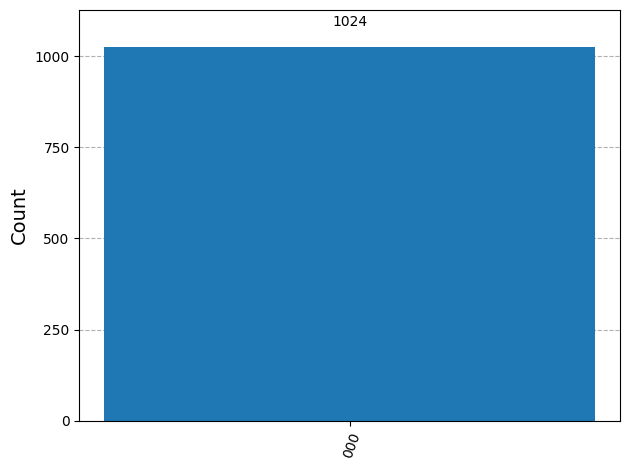

In [3]:
n = 3

# Constant function f(x) = 0
def constant_oracle(n):
    qc = QuantumCircuit(n + 1)

    # No operation is required for f(x)=0
    # The ancilla remains unchanged.

    return qc


# Deutsch-Jozsa circuit
def deutsch_jozsa_constant(n):
    qc = QuantumCircuit(n + 1, n)

    # Input qubits in |+>
    for i in range(n):
        qc.h(i)

    # Ancilla |1>
    qc.x(n)
    qc.h(n)

    # Oracle
    oracle = constant_oracle(n)
    qc.compose(oracle, qubits=range(n + 1), inplace=True)

    # Hadamard on input qubits
    for i in range(n):
        qc.h(i)

    # Measure input qubits
    qc.measure(range(n), range(n))

    return qc


qc = deutsch_jozsa_constant(3)

print(qc.draw())

compiled = transpile(qc, simulator)
result = simulator.run(compiled, shots=1024).result()
counts = result.get_counts()

print("Measurement results:", counts)

plot_histogram(counts)

# **Medium: Implement a balanced-function oracle (e.g., parity function) for 3 input qubits and verify a non-zero measurement result.**

     ┌───┐          ┌───┐     ┌─┐           
q_0: ┤ H ├───────■──┤ H ├─────┤M├───────────
     ├───┤       │  └───┘┌───┐└╥┘     ┌─┐   
q_1: ┤ H ├───────┼────■──┤ H ├─╫──────┤M├───
     ├───┤       │    │  └───┘ ║ ┌───┐└╥┘┌─┐
q_2: ┤ H ├───────┼────┼────■───╫─┤ H ├─╫─┤M├
     ├───┤┌───┐┌─┴─┐┌─┴─┐┌─┴─┐ ║ └───┘ ║ └╥┘
q_3: ┤ X ├┤ H ├┤ X ├┤ X ├┤ X ├─╫───────╫──╫─
     └───┘└───┘└───┘└───┘└───┘ ║       ║  ║ 
c: 3/══════════════════════════╩═══════╩══╩═
                               0       1  2 
Measurement results: {'111': 1024}


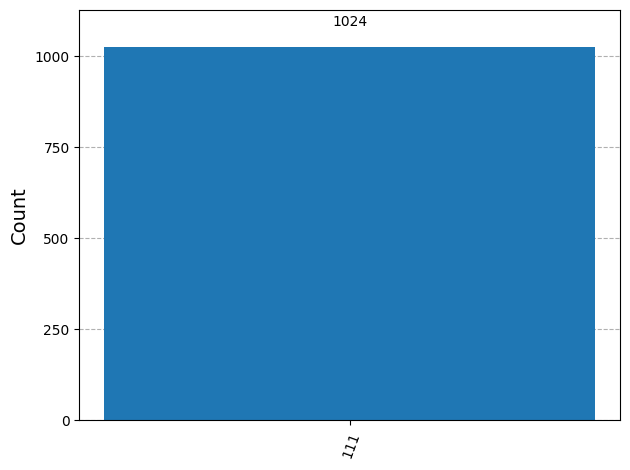

In [4]:
def parity_oracle(n):
    qc = QuantumCircuit(n + 1)

    # y -> y XOR x0 XOR x1 ... XOR xn
    for i in range(n):
        qc.cx(i, n)

    return qc


def deutsch_jozsa_balanced(n):
    qc = QuantumCircuit(n + 1, n)

    # Prepare input qubits
    for i in range(n):
        qc.h(i)

    # Prepare ancilla in |1>
    qc.x(n)
    qc.h(n)

    # Balanced oracle
    oracle = parity_oracle(n)
    qc.compose(oracle, qubits=range(n + 1), inplace=True)

    # Hadamard on input
    for i in range(n):
        qc.h(i)

    qc.measure(range(n), range(n))

    return qc


qc = deutsch_jozsa_balanced(3)

print(qc.draw())

compiled = transpile(qc, simulator)
result = simulator.run(compiled, shots=1024).result()
counts = result.get_counts()

print("Measurement results:", counts)

plot_histogram(counts)

# **Hard: Generalise the implementation to accept n as a parameter (n = 2 to 5) and automatically construct oracles for both cases.**

In [5]:
def constant_oracle_general(n, value=0):
    qc = QuantumCircuit(n + 1)

    # If f(x) = 1, flip the ancilla
    if value == 1:
        qc.x(n)

    return qc


def balanced_parity_oracle(n):
    qc = QuantumCircuit(n + 1)

    for i in range(n):
        qc.cx(i, n)

    return qc


def deutsch_jozsa(n, oracle):
    qc = QuantumCircuit(n + 1, n)

    # Input qubits |+>
    for i in range(n):
        qc.h(i)

    # Ancilla |1> -> |->
    qc.x(n)
    qc.h(n)

    # Oracle
    qc.compose(oracle, qubits=range(n + 1), inplace=True)

    # Hadamard on input
    for i in range(n):
        qc.h(i)

    # Measure input
    qc.measure(range(n), range(n))

    return qc

In [6]:
for n in range(2, 6):

    print("\n==============================")
    print("n =", n)

    # Constant oracle
    constant = constant_oracle_general(n, 0)
    qc_constant = deutsch_jozsa(n, constant)

    result = simulator.run(
        transpile(qc_constant, simulator),
        shots=512
    ).result()

    constant_counts = result.get_counts()

    print("Constant:", constant_counts)

    # Balanced parity oracle
    balanced = balanced_parity_oracle(n)
    qc_balanced = deutsch_jozsa(n, balanced)

    result = simulator.run(
        transpile(qc_balanced, simulator),
        shots=512
    ).result()

    balanced_counts = result.get_counts()

    print("Balanced:", balanced_counts)


n = 2
Constant: {'00': 512}
Balanced: {'11': 512}

n = 3
Constant: {'000': 512}
Balanced: {'111': 512}

n = 4
Constant: {'0000': 512}
Balanced: {'1111': 512}

n = 5
Constant: {'00000': 512}
Balanced: {'11111': 512}


# **Real-world: Plot classical worst-case query count versus quantum query count (always 1) for n = 2 to 10 to visually demonstrate the exponential gap.**

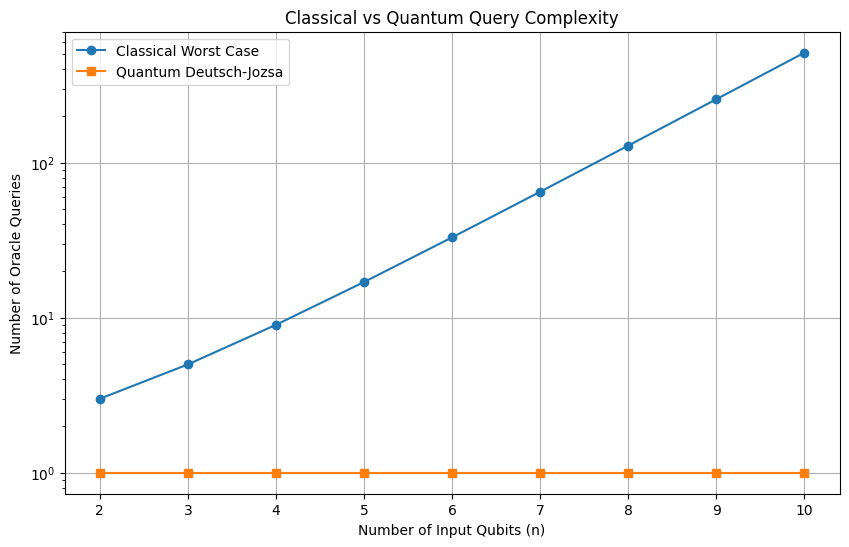

In [7]:
n_values = list(range(2, 11))

classical_queries = [2**(n - 1) + 1 for n in n_values]
quantum_queries = [1 for n in n_values]

plt.figure(figsize=(10, 6))

plt.plot(
    n_values,
    classical_queries,
    marker='o',
    label='Classical Worst Case'
)

plt.plot(
    n_values,
    quantum_queries,
    marker='s',
    label='Quantum Deutsch-Jozsa'
)

plt.xlabel("Number of Input Qubits (n)")
plt.ylabel("Number of Oracle Queries")
plt.title("Classical vs Quantum Query Complexity")
plt.xticks(n_values)
plt.yscale("log")
plt.grid(True)
plt.legend()

plt.show()

# **Challenge: Implement a randomised oracle generator that randomly picks a balanced function from all possible balanced functions for a given n, and verify the algorithm still correctly classifies it every time.**

In [8]:
def random_balanced_function(n):
    num_inputs = 2 ** n

    # Exactly half zeros and half ones
    outputs = [0] * (num_inputs // 2) + [1] * (num_inputs // 2)

    # Randomly shuffle the outputs
    np.random.shuffle(outputs)

    return outputs


def balanced_function_oracle(n, truth_table):
    qc = QuantumCircuit(n + 1)

    # For every input x for which f(x)=1,
    # apply a multi-controlled X gate.

    for x, output in enumerate(truth_table):

        if output == 1:

            binary = format(x, f'0{n}b')

            # Convert control qubits whose input bit is 0
            # so that all controls become 1.
            zero_positions = []

            for i, bit in enumerate(binary):
                if bit == '0':
                    zero_positions.append(i)

            # X gates for negative controls
            for i in zero_positions:
                qc.x(i)

            # Multi-controlled X
            controls = list(range(n))

            qc.mcx(controls, n)

            # Undo X gates
            for i in zero_positions:
                qc.x(i)

    return qc

In [9]:
n = 3

truth_table = random_balanced_function(n)

print("Random balanced truth table:")

for x, y in enumerate(truth_table):
    print(f"{format(x, f'0{n}b')} -> {y}")

print("\nNumber of 0 outputs:", truth_table.count(0))
print("Number of 1 outputs:", truth_table.count(1))

Random balanced truth table:
000 -> 0
001 -> 0
010 -> 1
011 -> 1
100 -> 1
101 -> 0
110 -> 1
111 -> 0

Number of 0 outputs: 4
Number of 1 outputs: 4
